In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
from dask.distributed import Client
client = Client()  # Automatically uses available cores
client

c:\Users\apoor\anaconda3\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56994 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:56994/status,
Dashboard: http://127.0.0.1:56994/status,Workers: 4
Total threads: 16,Total memory: 15.86 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:56995,Workers: 0
Dashboard: http://127.0.0.1:56994/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:63519,Total threads: 4
Dashboard: http://127.0.0.1:63520/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:56998,


2025-10-26 05:05:58,537 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17998s; attempting restart: <WorkerState 'tcp://127.0.0.1:63508', name: 3, status: running, memory: 0, processing: 0>
2025-10-26 05:05:58,842 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17998s; attempting restart: <WorkerState 'tcp://127.0.0.1:63510', name: 2, status: running, memory: 0, processing: 0>
2025-10-26 05:05:58,846 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17998s; attempting restart: <WorkerState 'tcp://127.0.0.1:63511', name: 1, status: running, memory: 0, processing: 0>
2025-10-26 05:05:58,848 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17998s; attempting restart: <WorkerState 'tcp://127.0.0.1:63519', name: 0, status: running, memory: 0, processing: 0>
2025-10-26 05:06:03,186 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-10-26 05:06:03,189 - distributed.nanny - WARNING 

In [4]:

data_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\pickup_coords_parquet.parquet"

pickup_coord_dataset = dd.read_parquet(data_path)

print("✅ Parquet file loaded with Dask!")
print(pickup_coord_dataset.head())

✅ Parquet file loaded with Dask!
   pickup_latitude  pickup_longitude
0        40.734695        -73.990372
1        40.729912        -73.980782
2        40.679565        -73.984550
3        40.718990        -73.993469
4        40.781330        -73.960625


In [7]:
rows = pickup_coord_dataset.shape[0].compute()
cols = len(pickup_coord_dataset.columns)
print(f"Shape: ({rows}, {cols})")

Shape: (33234199, 2)


In [12]:

sample_df = pickup_coord_dataset.sample(frac=0.1, random_state=42)  # 1% sample
print("Sample size:", sample_df.shape)


Sample size: (<dask_expr.expr.Scalar: expr=(Sample(frame=ReadParquetFSSpec(76af691), state_data=[array([1608637542, 3421126067, 4083286876,  787846414, 3143890026,
       3348747335, 2571218620, 2563451924,  670094950, 1914837113,
        669991378,  429389014,  249467210, 1972458954, 3720198231,
       1433267572, 2581769315,  613608295, 3041148567, 2795544706,
         88409749,  242285876, 4165731073, 3100961111, 3575313899,
       4031053213,  911989541,    3344769,  780932287, 4261516219,
        787716372, 2652062880, 1306710475, 2627030329, 2253811733,
         30349564, 1855189739,   99052376, 1250819632, 2253890010,
       2627888186, 1717389822,  599121577,  200427519, 1254751707,
       4182248123, 1573512143,  999745294, 1958805693,  389151677,
       3372305070, 2655947709,  857592370, 1642661739, 2208620086,
       4222944499, 2544401215, 2004731384,  199502978, 3693415908,
       2609385266, 2921898630,  732395540, 1934879560,  279394470,
         56972561, 4075432323, 4

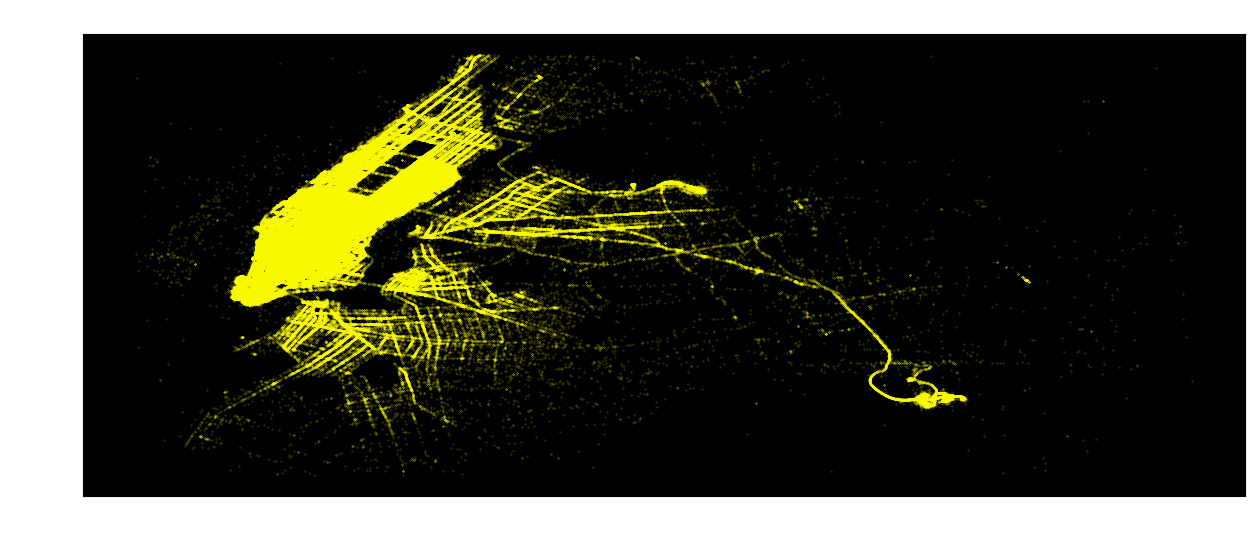

In [13]:

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('k')  # black background for contrast

# Use small points for density
ax.scatter(
    sample_df['pickup_longitude'],
    sample_df['pickup_latitude'],
    s=0.05,
    color='yellow',
    alpha=0.5
)

ax.set_title('Heatmap for NYC Taxi Pickups', fontsize=16, color='white')
ax.set_xlabel('Longitude', fontsize=12, color='white')
ax.set_ylabel('Latitude', fontsize=12, color='white')

# Set dark theme for axis text
ax.tick_params(colors='white')

plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
# Configure sklearn to return DataFrame
set_config(transform_output='pandas')

# Initialize scaler
scaler = StandardScaler()

# Fit + transform on coordinates
scaled_coords = scaler.fit_transform(sample_df)

# Optional: rename columns for clarity
scaled_coords.columns = ['pickup_longitude_scaled', 'pickup_latitude_scaled']

print("✅ Scaled dataset ready!")
print(scaled_coords.head())

✅ Scaled dataset ready!
   pickup_longitude_scaled  pickup_latitude_scaled
0                 1.073590               -0.202710
1                 1.075829                0.520330
2                 0.229638                0.199531
3                -0.068284               -0.161885
4                -0.667349               -0.358550


In [15]:
scaled_coords

,pickup_longitude_scaled,pickup_latitude_scaled
0,1.073590,-0.202710
1,1.075829,0.520330
2,0.229638,0.199531
3,-0.068284,-0.161885
4,-0.667349,-0.358550
...,...,...
3323415,0.062555,-0.034850
3323416,0.161770,-0.030706
3323417,-1.656273,-0.874563
3323418,0.191436,0.222327


Text(0, 0.5, 'Longitude')

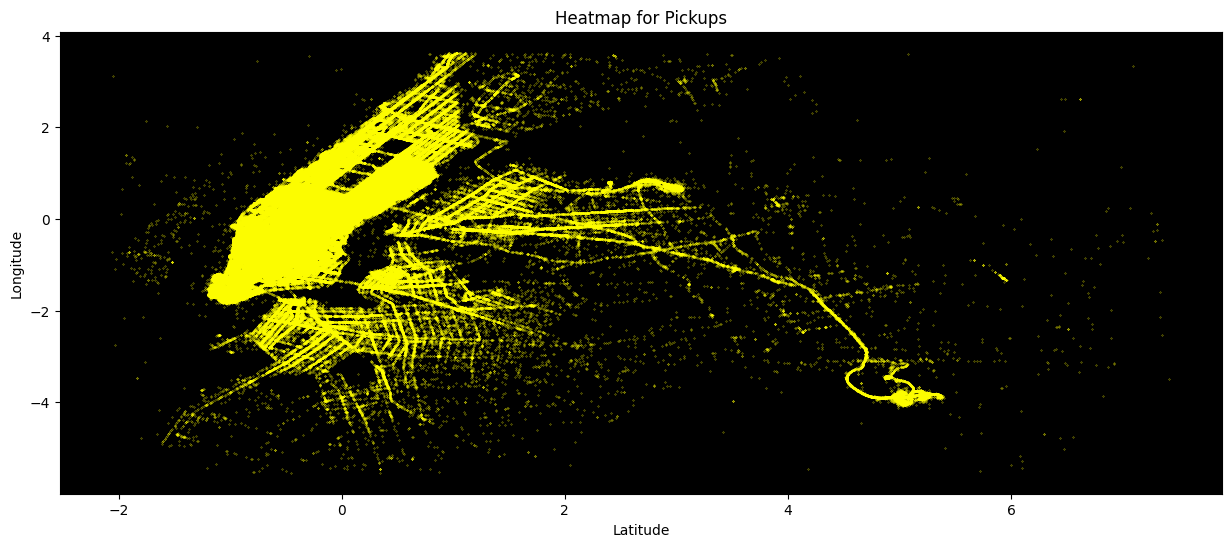

In [17]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(y=scaled_coords['pickup_longitude_scaled'],x=scaled_coords['pickup_latitude_scaled'],s=0.05,color='yellow')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

In [19]:
from sklearn.cluster import MiniBatchKMeans
# ============================================================
# ⚙️ CONFIGURATION
# ============================================================

data_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\pickup_coords_parquet.parquet"

# Chunksize for memory-safe processing
CHUNK_SIZE = 100_000

# Range of cluster values to test
possible_k_values = np.arange(10, 100, 10)

In [20]:
# ============================================================
# 🧠 STEP 1 — Train the StandardScaler incrementally
# ============================================================

scaler = StandardScaler()

print("🧩 Fitting StandardScaler incrementally...")
df_reader = pd.read_parquet(data_path, engine='pyarrow', columns=['pickup_latitude', 'pickup_longitude'])

# Fit scaler on all data in chunks
for i in range(0, len(df_reader), CHUNK_SIZE):
    chunk = df_reader.iloc[i:i+CHUNK_SIZE]
    scaler.partial_fit(chunk)

print("✅ Scaler fitted successfully.")
print("Mean values:", scaler.mean_)
print("Scale (std) values:", scaler.scale_)

🧩 Fitting StandardScaler incrementally...
✅ Scaler fitted successfully.
Mean values: [ 40.75107121 -73.9740618 ]
Scale (std) values: [0.02722268 0.03675237]


In [21]:
# ============================================================
# 🧮 STEP 2 — Define Haversine Distance Function
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance (in miles) between two points.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    earth_radius = 3958.8  # miles
    return earth_radius * c

In [22]:
# ============================================================
# 🔍 STEP 3 — Evaluate Different K values
# ============================================================

def select_optimum_k(k_values, data_path, scaler):
    for k in k_values:
        print(f"\n🔹 Training MiniBatchKMeans for k={k} clusters...")
        mini_batch = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
        
        # Read file in chunks
        df_reader = pd.read_parquet(data_path, engine='pyarrow', columns=['pickup_latitude', 'pickup_longitude'])
        for i in range(0, len(df_reader), CHUNK_SIZE):
            chunk = df_reader.iloc[i:i+CHUNK_SIZE]
            scaled_chunk = scaler.transform(chunk)
            mini_batch.partial_fit(scaled_chunk)
        
        # Get real-world cluster centers
        centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

        # Compute pairwise haversine distances between centroids
        all_distances = np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                all_distances[i, j] = haversine_distance(
                    centroids[i, 0], centroids[i, 1],
                    centroids[j, 0], centroids[j, 1]
                )

        # Sort distances for each centroid
        sorted_distances = np.sort(all_distances, axis=-1)

        # Take avg of nearest 8 neighboring clusters
        region_count = 8
        selected_distances = sorted_distances[:, 1:region_count+1]
        avg_distances = selected_distances.mean(axis=1)

        # Calculate % of clusters whose avg distance is between 1–1.5 miles
        within_range = ((avg_distances >= 1.0) & (avg_distances <= 1.5))
        percentage = within_range.mean() * 100

        print(f"✅ For {k} clusters → {within_range.sum()} zones (~{percentage:.1f}%) "
              f"have average neighbor distance 1–1.5 miles.")

In [23]:
# ============================================================
# 🚀 STEP 4 — Run K Evaluation
# ============================================================

select_optimum_k(k_values=possible_k_values, data_path=data_path, scaler=scaler)

# ============================================================
# 🏁 STEP 5 — Train Final Model with Optimum K
# ============================================================

# Suppose best K = 30 (from results)
best_k = 30
mini_batch = MiniBatchKMeans(n_clusters=best_k, n_init=10, random_state=42)

df_reader = pd.read_parquet(data_path, engine='pyarrow', columns=['pickup_latitude', 'pickup_longitude'])
for i in range(0, len(df_reader), CHUNK_SIZE):
    chunk = df_reader.iloc[i:i+CHUNK_SIZE]
    scaled_chunk = scaler.transform(chunk)
    mini_batch.partial_fit(scaled_chunk)

# Get final centroids in real coordinates
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

print(f"\n✅ Final model trained with k={best_k} clusters.")
print("Centroids shape:", centroids.shape)
print(centroids[:5])  # show first few cluster centers


🔹 Training MiniBatchKMeans for k=10 clusters...
✅ For 10 clusters → 0 zones (~0.0%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=20 clusters...
✅ For 20 clusters → 6 zones (~30.0%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=30 clusters...
✅ For 30 clusters → 9 zones (~30.0%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=40 clusters...
✅ For 40 clusters → 8 zones (~20.0%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=50 clusters...
✅ For 50 clusters → 7 zones (~14.0%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=60 clusters...
✅ For 60 clusters → 10 zones (~16.7%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=70 clusters...
✅ For 70 clusters → 13 zones (~18.6%) have average neighbor distance 1–1.5 miles.

🔹 Training MiniBatchKMeans for k=80 clusters...
✅ For 80 clusters → 14 zones (~17.5%) ha

In [ ]:
# ============================================================
# 🏁 STEP 5 — Train Final Model with Optimum K
# ============================================================


best_k = 30
mini_batch = MiniBatchKMeans(n_clusters=best_k, n_init=10, random_state=42)

df_reader = pd.read_parquet(data_path, engine='pyarrow', columns=['pickup_latitude', 'pickup_longitude'])
for i in range(0, len(df_reader), CHUNK_SIZE):
    chunk = df_reader.iloc[i:i+CHUNK_SIZE]
    scaled_chunk = scaler.transform(chunk)
    mini_batch.partial_fit(scaled_chunk)

# Get final centroids in real coordinates
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

print(f"\n✅ Final model trained with k={best_k} clusters.")
print("Centroids shape:", centroids.shape)
print(centroids[:5])  # show first few cluster center


✅ Final model trained with k=30 clusters.
Centroids shape: (30, 2)
[[ 40.80392392 -73.94975046]
 [ 40.74726528 -73.97685385]
 [ 40.69670159 -73.92094427]
 [ 40.64663525 -73.78474354]
 [ 40.7193993  -74.00391496]]


In [25]:

# ============================================================
# 🎯 STEP 6 — Distance Matrix for Final Clusters
# ============================================================

all_distances = np.zeros((best_k, best_k))
for i in range(best_k):
    for j in range(best_k):
        all_distances[i, j] = haversine_distance(
            centroids[i, 0], centroids[i, 1],
            centroids[j, 0], centroids[j, 1]
        )

print("\nAll distances matrix shape:", all_distances.shape)

# Sort and analyze
sorted_distances = np.sort(all_distances, axis=-1)
selected_distances = sorted_distances[:, 1:9]  # nearest 8 regions
avg_distances = selected_distances.mean(axis=1)

print("\nAverage neighbor distances (first 10):")
print(avg_distances[:10])

percentage = ((avg_distances >= 1.0) & (avg_distances <= 1.5)).mean() * 100
print(f"\n🎯 {percentage:.1f}% of regions are geographically compact (1–1.5 miles apart).")


All distances matrix shape: (30, 30)

Average neighbor distances (first 10):
[2.29703004 0.89876963 3.52859488 9.97718537 1.40925875 0.86804628
 4.59834916 0.88208569 1.59066958 2.26646269]

🎯 30.0% of regions are geographically compact (1–1.5 miles apart).


In [26]:

# ============================================================
# ⚙️ CONFIGURATION
# ============================================================
data_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\pickup_coords_parquet.parquet"
CHUNK_SIZE = 100_000
best_k = 30   # chosen number of clusters

In [27]:
# ============================================================
# 🧠 STEP 1 — LOAD DATA
# ============================================================
print("📥 Loading pickup coordinates from Parquet...")
pickup_coord_dataset = pd.read_parquet(data_path, engine='pyarrow')
print("✅ Loaded:", pickup_coord_dataset.shape, "records")

📥 Loading pickup coordinates from Parquet...
✅ Loaded: (33234199, 2) records


In [28]:
# ============================================================
# 🧩 STEP 2 — SCALE COORDINATES
# ============================================================
scaler = StandardScaler()
scaler.fit(pickup_coord_dataset[['pickup_latitude', 'pickup_longitude']])

scaled_data = scaler.transform(pickup_coord_dataset[['pickup_latitude', 'pickup_longitude']])
print("✅ Data scaled successfully.")


✅ Data scaled successfully.


In [29]:
# ============================================================
# ⚡ STEP 3 — TRAIN MINI-BATCH KMEANS
# ============================================================
mini_batch = MiniBatchKMeans(n_clusters=best_k, n_init=10, random_state=42)

# Split into chunks for incremental learning
for i in range(0, len(scaled_data), CHUNK_SIZE):
    batch = scaled_data[i:i+CHUNK_SIZE]
    mini_batch.partial_fit(batch)

print("✅ MiniBatchKMeans trained successfully.")
print("Centroid shape:", mini_batch.cluster_centers_.shape)

# Get centroids in original (lat-long) coordinates
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=['pickup_latitude', 'pickup_longitude'])
centroids_df.to_csv("data/final_cluster_centroids.csv", index=False)
print("💾 Centroids saved → data/final_cluster_centroids.csv")


✅ MiniBatchKMeans trained successfully.
Centroid shape: (30, 2)
💾 Centroids saved → data/final_cluster_centroids.csv


In [30]:
# ============================================================
# 🎯 STEP 4 — CLUSTER PREDICTIONS FOR SAMPLE DATA
# ============================================================

# Sample a small subset for visualization (faster)
sample_df = pickup_coord_dataset.sample(frac=0.01, random_state=42)
scaled_sample_df = scaler.transform(sample_df[['pickup_latitude', 'pickup_longitude']])

# Predict cluster for each sampled point
sample_predictions = mini_batch.predict(scaled_sample_df)
print("✅ Predictions completed for sample:", sample_predictions.shape)

✅ Predictions completed for sample: (332342,)


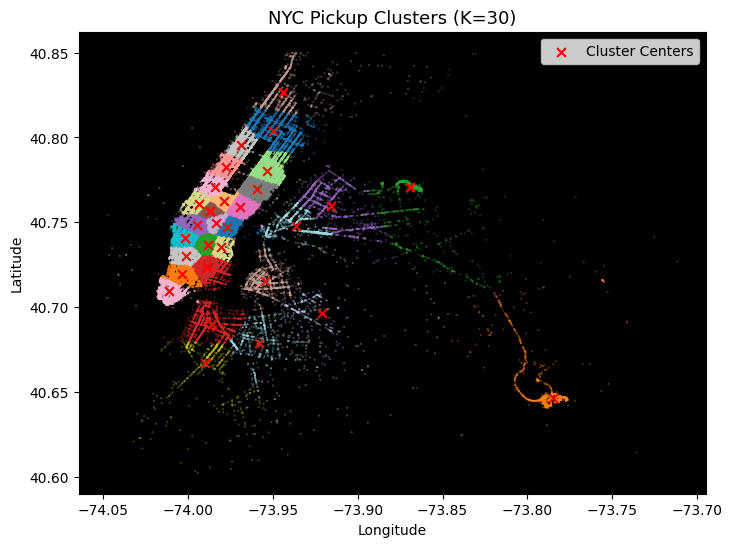

In [31]:
# ============================================================
# 📊 STEP 5 — VISUALIZE CLUSTERS ON SCATTERPLOT
# ============================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.set_facecolor('k')

# Plot pickups colored by cluster
sc = ax.scatter(
    sample_df['pickup_longitude'],  # X-axis
    sample_df['pickup_latitude'],   # Y-axis
    s=0.05,                         # smaller marker size for dense data
    c=sample_predictions,           # cluster-based coloring
    cmap='tab20',                   # colormap
    alpha=0.8
)

# Plot centroids
ax.scatter(
    centroids_df['pickup_longitude'],
    centroids_df['pickup_latitude'],
    color='red', s=40, marker='x', label='Cluster Centers'
)

ax.set_aspect('equal', adjustable='box')
ax.set_title('NYC Pickup Clusters (K=30)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.show()

In [32]:
print(type(type))

<class 'type'>
